In [29]:
import pandas as pd

import pandas as pd

files = [
    "api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv",
    "api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv",
    "api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv"
]

df_list = []

for file in files:
    print(f"Loading {file}")
    temp = pd.read_csv(file)
    df_list.append(temp)

enrol = pd.concat(df_list, ignore_index=True)

print("Combined shape:", enrol.shape)
print(enrol.head())


Loading api_data_aadhar_enrolment/api_data_aadhar_enrolment_0_500000.csv
Loading api_data_aadhar_enrolment/api_data_aadhar_enrolment_500000_1000000.csv
Loading api_data_aadhar_enrolment/api_data_aadhar_enrolment_1000000_1006029.csv
Combined shape: (1006029, 7)
         date          state          district  pincode  age_0_5  age_5_17  \
0  02-03-2025      Meghalaya  East Khasi Hills   793121       11        61   
1  09-03-2025      Karnataka   Bengaluru Urban   560043       14        33   
2  09-03-2025  Uttar Pradesh      Kanpur Nagar   208001       29        82   
3  09-03-2025  Uttar Pradesh           Aligarh   202133       62        29   
4  09-03-2025      Karnataka   Bengaluru Urban   560016       14        16   

   age_18_greater  
0              37  
1              39  
2              12  
3              15  
4              21  


In [30]:
# Convert date
enrol['date'] = pd.to_datetime(enrol['date'], dayfirst=True, errors='coerce')

# Extract year & month
enrol['year'] = enrol['date'].dt.year
enrol['month'] = enrol['date'].dt.month

# Create total enrolment
enrol['total_enrolment'] = (
    enrol['age_0_5'] +
    enrol['age_5_17'] +
    enrol['age_18_greater']
)


In [31]:
print(enrol['date'].isnull().sum())
enrol[['date', 'year', 'month']].head()


0


,date,year,month
0,2025-03-02,2025,3
1,2025-03-09,2025,3
2,2025-03-09,2025,3
3,2025-03-09,2025,3
4,2025-03-09,2025,3


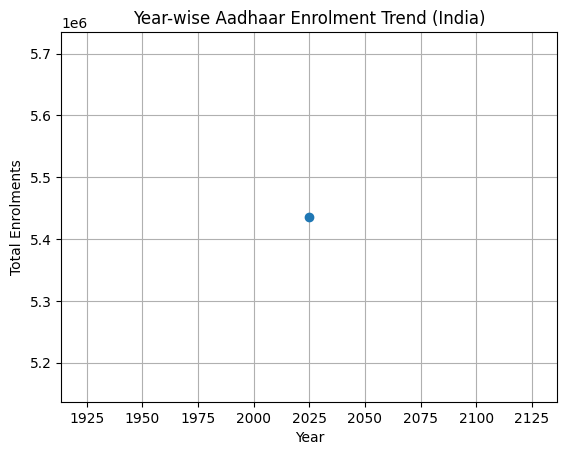

In [32]:
import matplotlib.pyplot as plt

yearly = enrol.groupby('year')['total_enrolment'].sum()

yearly.plot(kind='line', marker='o')
plt.title("Year-wise Aadhaar Enrolment Trend (India)")
plt.xlabel("Year")
plt.ylabel("Total Enrolments")
plt.grid(True)
plt.show()

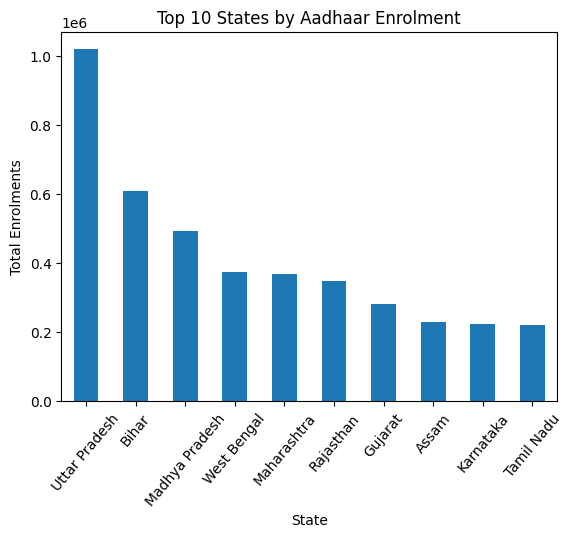

In [33]:
state_total = (
    enrol.groupby('state')['total_enrolment']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

state_total.plot(kind='bar')
plt.title("Top 10 States by Aadhaar Enrolment")
plt.xlabel("State")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=50)
plt.show()


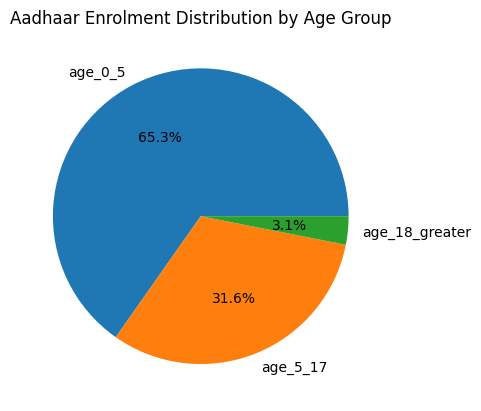

In [34]:
age_cols = ['age_0_5', 'age_5_17', 'age_18_greater']

age_distribution = enrol[age_cols].sum()

age_distribution.plot(kind='pie', autopct='%1.1f%%')
plt.title("Aadhaar Enrolment Distribution by Age Group")

plt.show()


In [35]:
age_state = enrol.groupby('state')[['age_0_5','age_5_17','age_18_greater']].sum()

age_state.head(5)



,age_0_5,age_5_17,age_18_greater
state,,,
100000,0,1,217
Andaman & Nicobar Islands,109,5,0
Andaman and Nicobar Islands,370,27,0
Andhra Pradesh,112440,13746,1495
Arunachal Pradesh,1957,2236,151


In [36]:
district_total = (
    enrol.groupby(['state','district'])['total_enrolment']
    .sum()
    .sort_values(ascending=False)
)

district_total.head(10)


state          district         
Maharashtra    Thane                43688
Bihar          Sitamarhi            42232
Uttar Pradesh  Bahraich             39338
West Bengal    Murshidabad          35911
               South 24 Parganas    33540
Maharashtra    Pune                 31763
Rajasthan      Jaipur               31146
Karnataka      Bengaluru            30980
Uttar Pradesh  Sitapur              30854
Bihar          West Champaran       30438
Name: total_enrolment, dtype: int64

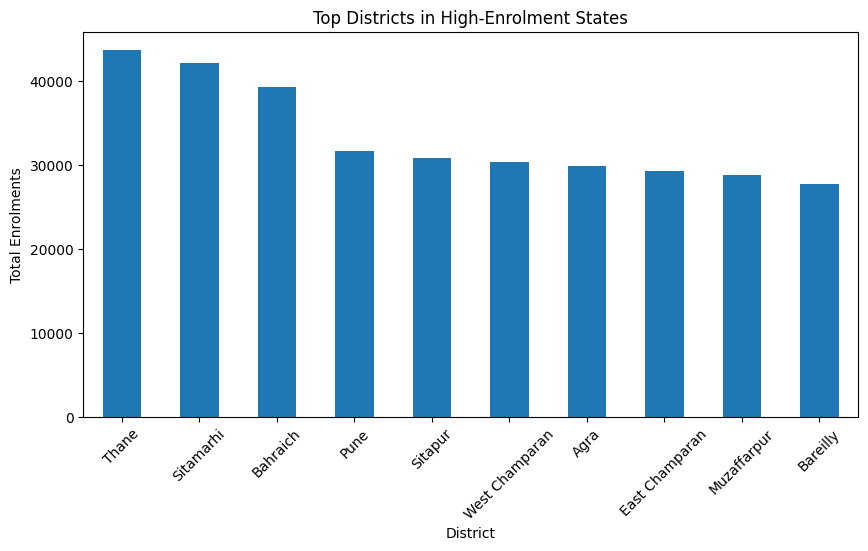

In [37]:
top_states = ['Uttar Pradesh','Bihar','Madhya Pradesh','Maharashtra']

district_top_states = (
    enrol[enrol['state'].isin(top_states)]
    .groupby('district')['total_enrolment']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

district_top_states.plot(kind='bar', figsize=(10,5))
plt.title("Top Districts in High-Enrolment States")
plt.xlabel("District")
plt.ylabel("Total Enrolments")
plt.xticks(rotation=45)
plt.show()


In [38]:

files = [
    "api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv",
    "api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv",
    "api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv",
    "api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv",
    "api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv"
]

df_list = []

for file in files:
    print(f"Loading {file}")
    temp = pd.read_csv(file)
    df_list.append(temp)

update = pd.concat(df_list, ignore_index=True)

print("Combined shape:", update.shape)
print(update.head())


Loading api_data_aadhar_demographic/api_data_aadhar_demographic_0_500000.csv
Loading api_data_aadhar_demographic/api_data_aadhar_demographic_500000_1000000.csv
Loading api_data_aadhar_demographic/api_data_aadhar_demographic_1000000_1500000.csv
Loading api_data_aadhar_demographic/api_data_aadhar_demographic_1500000_2000000.csv
Loading api_data_aadhar_demographic/api_data_aadhar_demographic_2000000_2071700.csv
Combined shape: (2071700, 6)
         date           state    district  pincode  demo_age_5_17  \
0  01-03-2025   Uttar Pradesh   Gorakhpur   273213             49   
1  01-03-2025  Andhra Pradesh    Chittoor   517132             22   
2  01-03-2025         Gujarat      Rajkot   360006             65   
3  01-03-2025  Andhra Pradesh  Srikakulam   532484             24   
4  01-03-2025       Rajasthan     Udaipur   313801             45   

   demo_age_17_  
0           529  
1           375  
2           765  
3           314  
4           785  


In [39]:
update['date'] = pd.to_datetime(
    update['date'],
    dayfirst=True,
    errors='coerce'
)

update['year'] = update['date'].dt.year


In [40]:
update['date'].isna().sum()


np.int64(0)

In [41]:
bio_files = [
    "api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv",
    "api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv",
    "api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv",
    "api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv"
]

bio_list = []

for file in bio_files:
    print(f"Loading {file}")
    temp = pd.read_csv(file)
    bio_list.append(temp)

bio = pd.concat(bio_list, ignore_index=True)

print("Biometric shape:", bio.shape)
bio.head()


Loading api_data_aadhar_biometric/api_data_aadhar_biometric_0_500000.csv
Loading api_data_aadhar_biometric/api_data_aadhar_biometric_500000_1000000.csv
Loading api_data_aadhar_biometric/api_data_aadhar_biometric_1000000_1500000.csv
Loading api_data_aadhar_biometric/api_data_aadhar_biometric_1500000_1861108.csv
Biometric shape: (1861108, 6)


,date,state,district,pincode,bio_age_5_17,bio_age_17_
0,01-03-2025,Haryana,Mahendragarh,123029,280,577
1,01-03-2025,Bihar,Madhepura,852121,144,369
2,01-03-2025,Jammu and Kashmir,Punch,185101,643,1091
3,01-03-2025,Bihar,Bhojpur,802158,256,980
4,01-03-2025,Tamil Nadu,Madurai,625514,271,815


In [42]:
bio['date'] = pd.to_datetime(
    bio['date'],
    dayfirst=True,
    errors='coerce'
)

bio['year'] = bio['date'].dt.year


In [43]:
bio['date'].isna().sum()


np.int64(0)

In [44]:
bio['total_biometric'] = (
    bio['bio_age_5_17'] +
    bio['bio_age_17_']
)


In [45]:
bio[['state', 'total_biometric']].head()


,state,total_biometric
0,Haryana,857
1,Bihar,513
2,Jammu and Kashmir,1734
3,Bihar,1236
4,Tamil Nadu,1086


In [46]:
enrol['total_enrolment'] = (
    enrol['age_0_5'] +
    enrol['age_5_17'] +
    enrol['age_18_greater']
)


In [47]:
update['total_update'] = (
    update['demo_age_5_17'] +
    update['demo_age_17_']
)


In [48]:
state_enrol = enrol.groupby('state')['total_enrolment'].sum()
state_update = update.groupby('state')['total_update'].sum()
state_bio = bio.groupby('state')['total_biometric'].sum()


In [49]:
comparison = pd.concat(
    [state_enrol, state_update, state_bio],
    axis=1
).fillna(0)

comparison.columns = ['Enrolment', 'Update', 'Biometric']
comparison.head()


,Enrolment,Update,Biometric
state,,,
100000,218.0,2.0,0.0
Andaman & Nicobar Islands,114.0,1059.0,2384.0
Andaman and Nicobar Islands,397.0,6187.0,18314.0
Andhra Pradesh,127681.0,2295505.0,3714592.0
Arunachal Pradesh,4344.0,36443.0,72394.0


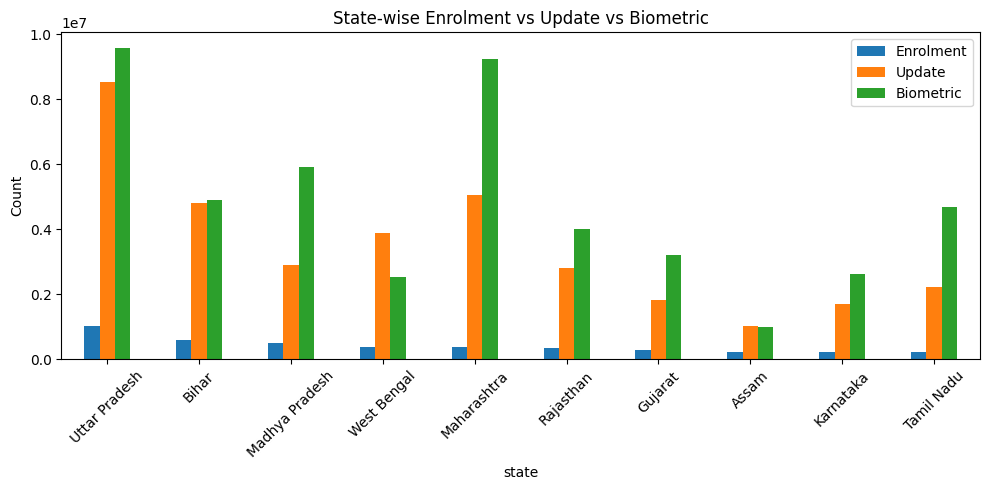

In [50]:
comparison.sort_values('Enrolment', ascending=False).head(10).plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("State-wise Enrolment vs Update vs Biometric")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("state_enrol_update_bio.png", dpi=300)
plt.show()


In [51]:
comparison['update_ratio'] = comparison['Update'] / comparison['Enrolment']
comparison['biometric_ratio'] = comparison['Biometric'] / comparison['Enrolment']
comparison[['Enrolment', 'Update', 'Biometric', 'update_ratio', 'biometric_ratio']].head()



,Enrolment,Update,Biometric,update_ratio,biometric_ratio
state,,,,,
100000,218.0,2.0,0.0,0.009174,0.000000
Andaman & Nicobar Islands,114.0,1059.0,2384.0,9.289474,20.912281
Andaman and Nicobar Islands,397.0,6187.0,18314.0,15.584383,46.130982
Andhra Pradesh,127681.0,2295505.0,3714592.0,17.978438,29.092755
Arunachal Pradesh,4344.0,36443.0,72394.0,8.389273,16.665285


In [52]:
comparison.sort_values(
    'update_ratio',
    ascending=False
).head(10)


,Enrolment,Update,Biometric,update_ratio,biometric_ratio
state,,,,,
odisha,0.0,20.0,16.0,inf,inf
West Bengli,0.0,3.0,0.0,inf,NaN
Uttaranchal,0.0,5.0,2.0,inf,inf
Raja Annamalai Puram,0.0,1.0,0.0,inf,NaN
Puttenahalli,0.0,1.0,0.0,inf,NaN
Nagpur,0.0,1.0,0.0,inf,NaN
west Bengal,0.0,15.0,1.0,inf,inf
Jaipur,0.0,2.0,0.0,inf,NaN
Darbhanga,0.0,2.0,0.0,inf,NaN


In [53]:
comparison.sort_values(
    'biometric_ratio'
).head(10)


,Enrolment,Update,Biometric,update_ratio,biometric_ratio
state,,,,,
100000,218.0,2.0,0.0,0.009174,0.000000
Jammu And Kashmir,950.0,0.0,0.0,0.000000,0.000000
The Dadra And Nagar Haveli And Daman And Diu,716.0,0.0,0.0,0.000000,0.000000
Meghalaya,109771.0,87378.0,87626.0,0.796003,0.798262
West Bengal,15.0,107.0,28.0,7.133333,1.866667
Jammu & Kashmir,155.0,426.0,429.0,2.748387,2.767742
West bengal,7.0,60.0,20.0,8.571429,2.857143
Westbengal,6.0,95.0,19.0,15.833333,3.166667
Assam,230197.0,1012578.0,982722.0,4.398745,4.269048


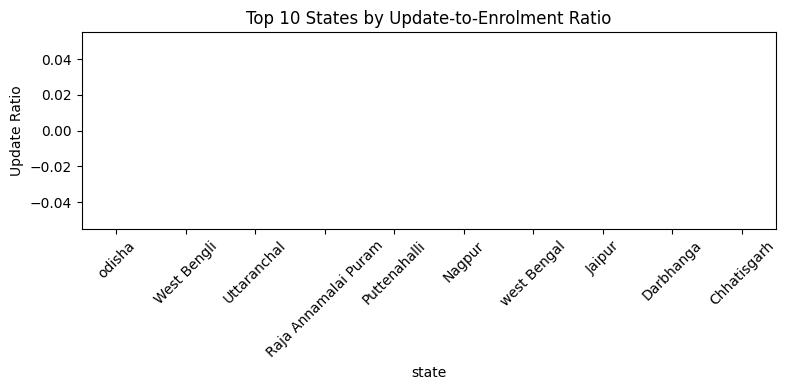

In [54]:
comparison.sort_values(
    'update_ratio',
    ascending=False
).head(10)['update_ratio'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title("Top 10 States by Update-to-Enrolment Ratio")
plt.ylabel("Update Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("update_ratio.png", dpi=300)
plt.show()


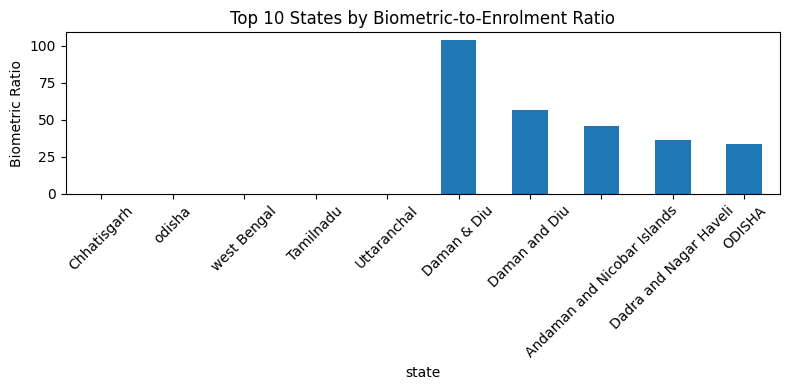

In [55]:
comparison.sort_values(
    'biometric_ratio',
    ascending=False
).head(10)['biometric_ratio'].plot(
    kind='bar',
    figsize=(8,4)
)

plt.title("Top 10 States by Biometric-to-Enrolment Ratio")
plt.ylabel("Biometric Ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("biometric_ratio.png", dpi=300)
plt.show()
